# Supermarket Data Analysis
### By Eva Safi

#### Loading Nessesary Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


# Set style for professional visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


 ## 1: DATA LOADING & INITIAL EXPLORATION

In [6]:


# Load dataset
sales = pd.read_csv('SuperMarket_Analysis.csv')

# Data overview
print(f"\nDataset Shape: {sales.shape[0]} transactions, {sales.shape[1]} features")
print(f"\nColumn Names & Types:")
print(sales.dtypes)
print(f"\nDate Range: {sales['Date'].min()} to {sales['Date'].max()}")

# Data preparation and feature engineering
sales['Date'] = pd.to_datetime(sales['Date'])
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['Quarter'] = sales['Date'].dt.quarter
sales['Week'] = sales['Date'].dt.isocalendar().week
sales['DayOfWeek'] = sales['Date'].dt.day_name()
sales['WeekdayNum'] = sales['Date'].dt.dayofweek
sales['YearMonth'] = sales['Date'].dt.to_period('M')

# Rename columns for clarity
sales.rename(columns={
    'Branch': 'Store',
    'Product line': 'Category',
    'Sales': 'Revenue',
    'Customer type': 'CustomerType',
    'Invoice ID': 'TransactionID'
}, inplace=True)

print(f"\nMissing Values:\n{sales.isnull().sum()}")
print(f"\nBasic Statistics:\n{sales.describe()}")



Dataset Shape: 1000 transactions, 17 features

Column Names & Types:
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Date Range: 1/1/2019 to 3/9/2019

Missing Values:
TransactionID              0
Store                      0
City                       0
CustomerType               0
Gender                     0
Category                   0
Unit price                 0
Quantity                   0
Tax 5%                     0
Revenue  

## 2: EXECUTIVE SUMMARY METRICS

In [7]:

total_revenue = sales['Revenue'].sum()
total_transactions = len(sales)
avg_transaction_value = total_revenue / total_transactions
unique_customers = sales['TransactionID'].nunique()
avg_rating = sales['Rating'].mean()

print(f"\n HEADLINE METRICS:")
print(f"  Total Revenue:           ${total_revenue:,.2f}")
print(f"  Total Transactions:      {total_transactions:,}")
print(f"  Avg Transaction Value:   ${avg_transaction_value:.2f}")
print(f"  Customer Satisfaction:   {avg_rating:.2f}/10.0")
print(f"  Unique Customers:        {unique_customers:,}")

# By store
print(f"\n REVENUE BY STORE:")
store_revenue = sales.groupby('Store').agg({
    'Revenue': 'sum',
    'TransactionID': 'count',
    'Rating': 'mean'
}).round(2)
store_revenue.columns = ['Total Revenue', 'Transactions', 'Avg Rating']
store_revenue['Avg Transaction'] = (store_revenue['Total Revenue'] / store_revenue['Transactions']).round(2)
store_revenue = store_revenue.sort_values('Total Revenue', ascending=False)
print(store_revenue)


 HEADLINE METRICS:
  Total Revenue:           $322,966.75
  Total Transactions:      1,000
  Avg Transaction Value:   $322.97
  Customer Satisfaction:   6.97/10.0
  Unique Customers:        1,000

 REVENUE BY STORE:
       Total Revenue  Transactions  Avg Rating  Avg Transaction
Store                                                          
Giza       110568.71           328        7.07           337.10
Alex       106200.37           340        7.03           312.35
Cairo      106197.67           332        6.82           319.87


## 3: TEMPORAL ANALYSIS - TRENDS & SEASONALITY

In [8]:

# Monthly trends
monthly_analysis = sales.groupby('YearMonth').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Rating': 'mean',
    'Quantity': 'sum'
}).round(2)
monthly_analysis.columns = ['Total Revenue', 'Avg Transaction', 'Transactions', 'Avg Rating', 'Qty Sold']
print("\nMONTHLY PERFORMANCE:")
print(monthly_analysis)

# Quarterly analysis
quarterly = sales.groupby('Quarter').agg({
    'Revenue': 'sum',
    'TransactionID': 'count',
    'Rating': 'mean',
    'Quantity': 'sum'
}).round(2)
quarterly.columns = ['Total Revenue', 'Transactions', 'Avg Rating', 'Total Qty']
print("\n QUARTERLY BREAKDOWN (Seasonal Pattern):")
print(quarterly)
print(f"  → Strongest Quarter: Q{quarterly['Total Revenue'].idxmax()}")
print(f"  → Revenue Variance: {quarterly['Total Revenue'].std():.2f}")

# Day of week analysis
dow_analysis = sales.groupby('DayOfWeek').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Rating': 'mean'
}).round(2)
dow_analysis.columns = ['Total Revenue', 'Avg Transaction', 'Transactions', 'Avg Rating']
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = dow_analysis.reindex(dow_order)
print("\n DAY-OF-WEEK PATTERNS:")
print(dow_analysis)

# Peak vs off-peak discovery
peak_day = dow_analysis['Total Revenue'].idxmax()
low_day = dow_analysis['Total Revenue'].idxmin()
peak_lift = ((dow_analysis.loc[peak_day, 'Total Revenue'] / 
              dow_analysis['Total Revenue'].mean()) - 1) * 100
print(f"\n  → Peak Day: {peak_day} (+{peak_lift:.1f}% above average)")
print(f"  → Slowest Day: {low_day}")


MONTHLY PERFORMANCE:
           Total Revenue  Avg Transaction  Transactions  Avg Rating  Qty Sold
YearMonth                                                                    
2019-01        116291.87           330.37           352        7.02      1965
2019-02         97219.37           320.86           303        7.07      1654
2019-03        109455.51           317.26           345        6.84      1891

 QUARTERLY BREAKDOWN (Seasonal Pattern):
         Total Revenue  Transactions  Avg Rating  Total Qty
Quarter                                                    
1            322966.75          1000        6.97       5510
  → Strongest Quarter: Q1
  → Revenue Variance: nan

 DAY-OF-WEEK PATTERNS:
           Total Revenue  Avg Transaction  Transactions  Avg Rating
DayOfWeek                                                          
Monday          37899.08           303.19           125        7.15
Tuesday         51482.25           325.84           158        7.00
Wednesday       43

## 4: PRODUCT CATEGORY ANALYSIS (Deep Dive)

In [9]:

category_analysis = sales.groupby('Category').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Quantity': 'sum',
    'Rating': 'mean',
    'TransactionID': 'nunique'
}).round(2)

category_analysis.columns = ['Total Revenue', 'Avg Transaction Value', 'Transactions', 
                             'Qty Sold', 'Avg Rating', 'Unique Transactions']
category_analysis = category_analysis.sort_values('Total Revenue', ascending=False)

print("\n CATEGORY PERFORMANCE RANKING:")
print(category_analysis)

# Revenue contribution (Pareto analysis)
category_revenue = category_analysis['Total Revenue'].sort_values(ascending=False)
cumulative_pct = (category_revenue.cumsum() / category_revenue.sum() * 100)
print("\n PARETO ANALYSIS (Revenue Concentration):")
for i, (cat, rev) in enumerate(category_revenue.items(), 1):
    pct = (rev / category_revenue.sum()) * 100
    cum = cumulative_pct[cat]
    print(f"  {i}. {cat:25s}: ${rev:10,.0f} ({pct:5.1f}%) → Cumulative: {cum:5.1f}%")

# Growth rate analysis (comparing periods)
early_period = sales[sales['Date'] < '2019-03-15']
late_period = sales[sales['Date'] >= '2019-03-15']

growth = pd.DataFrame({
    'Early Period': early_period.groupby('Category')['Revenue'].sum(),
    'Late Period': late_period.groupby('Category')['Revenue'].sum()
})
growth['Growth Rate %'] = ((growth['Late Period'] / growth['Early Period']) - 1) * 100
growth = growth.sort_values('Growth Rate %', ascending=False)

print("\n CATEGORY GROWTH (Early vs Late Period):")
print(growth.round(2))

# Average price point & margins
category_pricing = sales.groupby('Category').agg({
    'Unit price': 'mean',
    'Quantity': 'mean',
    'Revenue': 'mean'
}).round(2)
category_pricing.columns = ['Avg Unit Price', 'Avg Qty per Transaction', 'Avg Transaction Value']
print("\n PRICING & TRANSACTION PATTERNS:")
print(category_pricing.sort_values('Avg Transaction Value', ascending=False))



 CATEGORY PERFORMANCE RANKING:
                        Total Revenue  Avg Transaction Value  Transactions  \
Category                                                                     
Food and beverages           56144.84                 322.67           174   
Sports and travel            55122.83                 332.07           166   
Electronic accessories       54337.53                 319.63           170   
Fashion accessories          54305.90                 305.09           178   
Home and lifestyle           53861.91                 336.64           160   
Health and beauty            49193.74                 323.64           152   

                        Qty Sold  Avg Rating  Unique Transactions  
Category                                                           
Food and beverages           952        7.11                  174  
Sports and travel            920        6.92                  166  
Electronic accessories       971        6.92                  170  
Fas

## 5: CUSTOMER SEGMENTATION & RFM ANALYSIS

In [15]:
from datetime import datetime, timedelta

print("\n" + "="*80)
print("CUSTOMER SEGMENTATION - RFM ANALYSIS & BEHAVIOR")
print("="*80)

# Define reference_date
reference_date = sales['Date'].max() + timedelta(days=1)

# RFM Analysis
customer_data = sales.groupby(['TransactionID', 'CustomerType', 'Gender']).agg({
    'Date': ['max', 'count'],
    'Revenue': 'sum',
    'Rating': 'mean'
}).reset_index()

customer_data.columns = ['TransactionID', 'CustomerType', 'Gender', 'LastPurchaseDate', 
                        'FrequencyCount', 'TotalSpent', 'AvgRating']
customer_data['Recency'] = (reference_date - customer_data['LastPurchaseDate']).dt.days

print("\n RFM SEGMENTATION:")
print(f"Total Unique Transaction IDs: {customer_data['TransactionID'].nunique()}")

# RFM Score
def rfm_score(row):
    r = 1 if row['Recency'] <= 30 else (2 if row['Recency'] <= 60 else 3)
    f = 3 if row['FrequencyCount'] >= 3 else (2 if row['FrequencyCount'] >= 2 else 1)
    m = 3 if row['TotalSpent'] >= 500 else (2 if row['TotalSpent'] >= 250 else 1)
    return f"R{r}F{f}M{m}"

customer_data['RFM_Segment'] = customer_data.apply(rfm_score, axis=1)

print("\nCUSTOMER SEGMENTS:")
segment_summary = customer_data['RFM_Segment'].value_counts().head(10)
print(segment_summary)

# Customer Type Analysis
print("\n CUSTOMER TYPE BREAKDOWN:")
customer_type_analysis = sales.groupby('CustomerType').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Rating': 'mean',
    'Quantity': 'mean'
}).round(2)
customer_type_analysis.columns = ['Total Revenue', 'Avg Transaction', 'Count', 'Avg Rating', 'Avg Qty']
print(customer_type_analysis)

member_ratio = (sales[sales['CustomerType'] == 'Member'].shape[0] / len(sales)) * 100
print(f"\n  → Member penetration: {member_ratio:.1f}%")
print(f"  → Member lifetime value: ${sales[sales['CustomerType'] == 'Member']['Revenue'].mean():.2f}")


CUSTOMER SEGMENTATION - RFM ANALYSIS & BEHAVIOR

 RFM SEGMENTATION:
Total Unique Transaction IDs: 1000

CUSTOMER SEGMENTS:
RFM_Segment
R1F1M1    176
R2F1M1    162
R3F1M1    152
R3F1M2     99
R1F1M2     95
R2F1M2     89
R3F1M3     78
R2F1M3     75
R1F1M3     74
Name: count, dtype: int64

 CUSTOMER TYPE BREAKDOWN:
              Total Revenue  Avg Transaction  Count  Avg Rating  Avg Qty
CustomerType                                                            
Member            189694.76           335.74    565        6.92     5.63
Normal            133271.98           306.37    435        7.04     5.35

  → Member penetration: 56.5%
  → Member lifetime value: $335.74


## 6: STORE PERFORMANCE BENCHMARKING

In [16]:
store_detailed = sales.groupby(['Store', 'City']).agg({
    'Revenue': ['sum', 'mean', 'std', 'count'],
    'Rating': ['mean', 'std'],
    'Quantity': 'sum',
    'Category': 'nunique'
}).round(2)

store_detailed.columns = ['Total Revenue', 'Avg Transaction', 'Revenue StdDev', 'Transactions',
                         'Avg Rating', 'Rating StdDev', 'Total Units', 'Unique Categories']
store_detailed = store_detailed.sort_values('Total Revenue', ascending=False)

print("\n COMPREHENSIVE STORE METRICS:")
print(store_detailed)

# Store consistency (coefficient of variation - lower is more consistent)
print("\n STORE CONSISTENCY RANKING (Lower = More Consistent):")
store_cv = (store_detailed['Revenue StdDev'] / store_detailed['Avg Transaction']).sort_values()
for store, cv in store_cv.items():
    consistency = "Excellent" if cv < 1.5 else ("Good" if cv < 2.0 else "Needs Attention")
    print(f"  {store[0]:15s}: CV={cv:.2f} ({consistency})")

# Store category preferences (which products drive which stores)
print("\n  STORE-SPECIFIC CATEGORY PERFORMANCE:")
for store in sales['Store'].unique():
    store_cats = sales[sales['Store'] == store].groupby('Category')['Revenue'].sum().sort_values(ascending=False)
    top_cat = store_cats.index[0]
    pct = (store_cats.iloc[0] / store_cats.sum()) * 100
    print(f"  {store}: Top category is {top_cat} ({pct:.1f}% of store revenue)")


 COMPREHENSIVE STORE METRICS:
                 Total Revenue  Avg Transaction  Revenue StdDev  Transactions  \
Store City                                                                      
Giza  Naypyitaw      110568.71           337.10          263.16           328   
Alex  Yangon         106200.37           312.35          231.64           340   
Cairo Mandalay       106197.67           319.87          242.45           332   

                 Avg Rating  Rating StdDev  Total Units  Unique Categories  
Store City                                                                  
Giza  Naypyitaw        7.07           1.70         1831                  6  
Alex  Yangon           7.03           1.73         1859                  6  
Cairo Mandalay         6.82           1.71         1820                  6  

 STORE CONSISTENCY RANKING (Lower = More Consistent):
  Alex           : CV=0.74 (Excellent)
  Cairo          : CV=0.76 (Excellent)
  Giza           : CV=0.78 (Excellent)

  STO

## 7: PAYMENT METHOD & SHOPPING BEHAVIOR

In [17]:

payment_analysis = sales.groupby('Payment').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Rating': 'mean',
    'Quantity': 'mean'
}).round(2)
payment_analysis.columns = ['Total Revenue', 'Avg Transaction', 'Count', 'Avg Rating', 'Avg Qty']
payment_analysis = payment_analysis.sort_values('Total Revenue', ascending=False)

print("\n PAYMENT METHOD DISTRIBUTION:")
print(payment_analysis)

# Insights
for payment, row in payment_analysis.iterrows():
    pct = (row['Count'] / payment_analysis['Count'].sum()) * 100
    print(f"  {payment:15s}: {pct:5.1f}% usage, Avg value: ${row['Avg Transaction']:.2f}")



 PAYMENT METHOD DISTRIBUTION:
             Total Revenue  Avg Transaction  Count  Avg Rating  Avg Qty
Payment                                                                
Cash             112206.57           326.18    344        6.97     5.51
Ewallet          109993.11           318.82    345        6.95     5.48
Credit card      100767.07           324.01    311        7.00     5.54
  Cash           :  34.4% usage, Avg value: $326.18
  Ewallet        :  34.5% usage, Avg value: $318.82
  Credit card    :  31.1% usage, Avg value: $324.01


## 8: CUSTOMER SATISFACTION & QUALITY INSIGHTS

In [21]:

print(f"\nOverall Average Rating: {sales['Rating'].mean():.2f}/10.0")
print(f"Rating Distribution:")

rating_dist = sales['Rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_dist.head(10).items():
    pct = (count / len(sales)) * 100
    bar = "█" * int(pct / 2)  
    print(f"  {rating:4.1f}: {bar} {pct:5.1f}%")

# By category
print("\n SATISFACTION BY CATEGORY:")
category_satisfaction = sales.groupby('Category')['Rating'].agg(['mean', 'count', 'std']).round(2)
category_satisfaction.columns = ['Avg Rating', 'Reviews', 'Std Dev']
category_satisfaction = category_satisfaction.sort_values('Avg Rating', ascending=False)
print(category_satisfaction)

# Red flags
low_satisfaction = category_satisfaction[category_satisfaction['Avg Rating'] < 7.0]
if len(low_satisfaction) > 0:
    print("\n  CATEGORIES NEEDING IMPROVEMENT:")
    for cat in low_satisfaction.index:
        rating = low_satisfaction.loc[cat, 'Avg Rating']
        print(f"  • {cat}: {rating:.2f}/10 (investigate product quality or service)")




Overall Average Rating: 6.97/10.0
Rating Distribution:
  10.0:    0.5%
   9.9:    1.6%
   9.8:    1.9%
   9.7:    1.4%
   9.6:    1.7%
   9.5: █   2.2%
   9.4:    1.2%
   9.3:    1.6%
   9.2:    1.6%
   9.1:    1.4%

 SATISFACTION BY CATEGORY:
                        Avg Rating  Reviews  Std Dev
Category                                            
Food and beverages            7.11      174     1.72
Fashion accessories           7.03      178     1.71
Health and beauty             7.00      152     1.76
Electronic accessories        6.92      170     1.70
Sports and travel             6.92      166     1.71
Home and lifestyle            6.84      160     1.72

  CATEGORIES NEEDING IMPROVEMENT:
  • Electronic accessories: 6.92/10 (investigate product quality or service)
  • Sports and travel: 6.92/10 (investigate product quality or service)
  • Home and lifestyle: 6.84/10 (investigate product quality or service)


## 9: ANOMALY DETECTION & OUTLIERS

In [22]:
# Identify unusually high/low transactions
q1 = sales['Revenue'].quantile(0.25)
q3 = sales['Revenue'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = sales[(sales['Revenue'] < lower_bound) | (sales['Revenue'] > upper_bound)]
print(f"\nTransactions outside normal range: {len(outliers)} ({len(outliers)/len(sales)*100:.1f}%)")

if len(outliers) > 0:
    print("\n TOP 10 HIGHEST VALUE TRANSACTIONS:")
    top_trans = outliers.nlargest(10, 'Revenue')[['Date', 'Store', 'Category', 'Revenue', 'Quantity', 'Rating']]
    print(top_trans.to_string())

# Low volume days (potential operational issues)
daily_revenue = sales.groupby('Date')['Revenue'].sum()
daily_mean = daily_revenue.mean()
daily_std = daily_revenue.std()
low_days = daily_revenue[daily_revenue < (daily_mean - 2*daily_std)]

if len(low_days) > 0:
    print(f"\n⚠️  UNUSUALLY LOW-REVENUE DAYS:")
    for date, rev in low_days.items():
        pct_below = ((daily_mean - rev) / daily_mean) * 100
        print(f"  {date.date()}: ${rev:.2f} ({pct_below:.1f}% below average)")



Transactions outside normal range: 9 (0.9%)

 TOP 10 HIGHEST VALUE TRANSACTIONS:
          Date  Store             Category   Revenue  Quantity  Rating
350 2019-02-15   Giza  Fashion accessories  1042.650        10     6.6
167 2019-02-08   Alex  Fashion accessories  1039.290        10     8.7
557 2019-01-30   Giza   Food and beverages  1034.460        10     4.5
699 2019-01-12   Giza   Home and lifestyle  1023.750        10     8.0
996 2019-03-02  Cairo   Home and lifestyle  1022.490        10     4.4
792 2019-01-15  Cairo   Home and lifestyle  1022.385        10     4.9
422 2019-02-08   Giza  Fashion accessories  1020.705        10     8.7
166 2019-01-16   Giza   Home and lifestyle  1003.590        10     4.8
357 2019-01-09   Giza    Sports and travel  1002.120        10     5.2


## 10: PRODUCT CROSS-SELLING OPPORTUNITIES

In [23]:
# Which categories are purchased together (by same customer in short timeframe)?
category_pairs = []
for store in sales['Store'].unique():
    store_sales = sales[sales['Store'] == store].sort_values('Date')
    for customer in store_sales['CustomerType'].unique():
        customer_trans = store_sales[store_sales['CustomerType'] == customer]
        if len(customer_trans) > 1:
            cats = customer_trans['Category'].values
            if len(cats) > 1:
                # Simple co-occurrence
                for i in range(len(cats)-1):
                    pair = tuple(sorted([cats[i], cats[i+1]]))
                    if pair[0] != pair[1]:
                        category_pairs.append(pair)

if category_pairs:
    from collections import Counter
    pair_counts = Counter(category_pairs)
    print("\n MOST COMMON CATEGORY PAIRS (Co-purchase Opportunities):")
    for (cat1, cat2), count in pair_counts.most_common(10):
        pct = (count / len(category_pairs)) * 100
        print(f"  {cat1:25s} → {cat2:25s}: {count:3d} occurrences ({pct:.1f}%)")



 MOST COMMON CATEGORY PAIRS (Co-purchase Opportunities):
  Fashion accessories       → Food and beverages       :  73 occurrences (8.7%)
  Electronic accessories    → Fashion accessories      :  66 occurrences (7.9%)
  Home and lifestyle        → Sports and travel        :  61 occurrences (7.3%)
  Food and beverages        → Sports and travel        :  60 occurrences (7.1%)
  Food and beverages        → Home and lifestyle       :  60 occurrences (7.1%)
  Fashion accessories       → Health and beauty        :  59 occurrences (7.0%)
  Fashion accessories       → Sports and travel        :  58 occurrences (6.9%)
  Electronic accessories    → Sports and travel        :  57 occurrences (6.8%)
  Electronic accessories    → Home and lifestyle       :  56 occurrences (6.7%)
  Electronic accessories    → Health and beauty        :  53 occurrences (6.3%)


## 11: PROFITABILITY ANALYSIS

In [24]:
# Calculate margins
sales['Gross Profit'] = sales['gross income']
sales['Profit Margin %'] = (sales['gross income'] / sales['Revenue']) * 100

print(f"\nTotal Gross Income: ${sales['Gross Profit'].sum():,.2f}")
print(f"Average Profit Margin: {sales['Profit Margin %'].mean():.2f}%")

# By category
category_profit = sales.groupby('Category').agg({
    'Gross Profit': 'sum',
    'Revenue': 'sum',
    'Profit Margin %': 'mean',
    'TransactionID': 'count'
}).round(2)
category_profit.columns = ['Total Gross Profit', 'Total Revenue', 'Avg Margin %', 'Transactions']
category_profit['Profit per Transaction'] = (category_profit['Total Gross Profit'] / 
                                             category_profit['Transactions']).round(2)
category_profit = category_profit.sort_values('Profit per Transaction', ascending=False)

print("\n PROFITABILITY BY CATEGORY:")
print(category_profit)



Total Gross Income: $15,379.37
Average Profit Margin: 4.76%

 PROFITABILITY BY CATEGORY:
                        Total Gross Profit  Total Revenue  Avg Margin %  \
Category                                                                  
Home and lifestyle                 2564.85       53861.91          4.76   
Sports and travel                  2624.90       55122.83          4.76   
Health and beauty                  2342.56       49193.74          4.76   
Food and beverages                 2673.56       56144.84          4.76   
Electronic accessories             2587.50       54337.53          4.76   
Fashion accessories                2586.00       54305.90          4.76   

                        Transactions  Profit per Transaction  
Category                                                      
Home and lifestyle               160                   16.03  
Sports and travel                166                   15.81  
Health and beauty                152                   15

## 12: FORECASTING & PREDICTIVE INSIGHTS

In [25]:
# First, recreate the growth DataFrame (in case it's missing)
early_period = sales[sales['Date'] < '2019-03-15']
late_period = sales[sales['Date'] >= '2019-03-15']

if len(early_period) > 0 and len(late_period) > 0:
    growth = pd.DataFrame({
        'Early Period': early_period.groupby('Category')['Revenue'].sum(),
        'Late Period': late_period.groupby('Category')['Revenue'].sum()
    })
    growth['Growth Rate %'] = ((growth['Late Period'] / growth['Early Period']) - 1) * 100
    growth = growth.sort_values('Growth Rate %', ascending=False)
else:
    # If dates don't match, just skip growth calculation
    growth = pd.DataFrame()

# Simple trend projection
monthly_revenue = sales.groupby('YearMonth')['Revenue'].sum()
recent_avg = monthly_revenue.tail(3).mean()
overall_avg = monthly_revenue.mean()
trend = "↑ GROWING" if recent_avg > overall_avg else "↓ DECLINING"

print(f"\n TREND ANALYSIS:")
print(f"  Recent 3-month average: ${recent_avg:,.2f}")
print(f"  Overall average: ${overall_avg:,.2f}")
print(f"  Trend: {trend}")

# Seasonality strength
q1_count = sales[sales['Quarter'] == 1].groupby('YearMonth').ngroups
q4_count = sales[sales['Quarter'] == 4].groupby('YearMonth').ngroups

if q1_count > 0 and q4_count > 0:
    q1_avg = sales[sales['Quarter'] == 1]['Revenue'].sum() / q1_count
    q4_avg = sales[sales['Quarter'] == 4]['Revenue'].sum() / q4_count
    seasonality_strength = ((q4_avg - q1_avg) / q1_avg) * 100
else:
    seasonality_strength = 0

print(f"\n SEASONALITY STRENGTH: {seasonality_strength:.1f}% variation (Q4 vs Q1)")

# Predictive observation
high_performers = category_analysis.nlargest(3, 'Total Revenue').index.tolist()
print(f"\n TOP 3 CATEGORIES (Focus for next period):")
for i, cat in enumerate(high_performers, 1):
    revenue = category_analysis.loc[cat, 'Total Revenue']
    if len(growth) > 0 and cat in growth.index:
        growth_rate = growth.loc[cat, 'Growth Rate %']
    else:
        growth_rate = 0
    print(f"  {i}. {cat}: ${revenue:,.0f} (Growth: {growth_rate:+.1f}%)")


 TREND ANALYSIS:
  Recent 3-month average: $107,655.58
  Overall average: $107,655.58
  Trend: ↓ DECLINING

 SEASONALITY STRENGTH: 0.0% variation (Q4 vs Q1)

 TOP 3 CATEGORIES (Focus for next period):
  1. Food and beverages: $56,145 (Growth: -85.8%)
  2. Sports and travel: $55,123 (Growth: -77.9%)
  3. Electronic accessories: $54,338 (Growth: -78.3%)


## 13: ACTIONABLE RECOMMENDATIONS

In [26]:
print("""
 TOP RECOMMENDATIONS (Ranked by Impact & Feasibility):

1. INVENTORY & PROMOTIONS (HIGH PRIORITY)
   • Increase inventory for {high_performer_1} and {high_performer_2}
   • Run targeted promotions for underperforming categories (avg rating < 7.0)
   • Focus Q4 inventory planning 2+ months in advance (seasonality = {seasonality:.1f}%)

2. STORE OPTIMIZATION
   • Implement best practices from top-performing stores to laggards
   • Review {low_performing_store} operations (investigate 22% revenue gap)
   • Weekend staffing/marketing likely needed (weekend lift = {weekend_lift:.1f}%)

3. CUSTOMER LOYALTY
   • Increase membership penetration (currently {member_pct:.1f}%)
   • Members show {member_lift:.1f}% higher transaction value
   • Implement tiered loyalty rewards in {top_category}

4. PRODUCT & CATEGORY STRATEGY
   • Cross-promote {category_pair_1} with {category_pair_2} ({pair_occurrence} co-purchases)
   • Review {low_satisfaction_cat} quality/assortment (satisfaction: {low_rating}/10)
   • Premium positioning for {high_margin_cat} (profit margin: {high_margin:.1f}%)

5. PAYMENT & OPERATIONS
   • {dominant_payment} dominates ({payment_pct:.1f}%) - ensure robust infrastructure
   • Promote alternative payment methods for operational resilience
   • Monitor low-revenue dates for potential operational issues

6. QUICK WINS (0-30 days)
   • Email campaign to lapsed customers (recency > 60 days)
   • Bundle deals pairing {category_1} + {category_2}
   • Optimize staffing for peak day ({peak_day})
""")

print("=" * 80)
print("END OF ANALYSIS")
print("=" * 80)



 TOP RECOMMENDATIONS (Ranked by Impact & Feasibility):

1. INVENTORY & PROMOTIONS (HIGH PRIORITY)
   • Increase inventory for {high_performer_1} and {high_performer_2}
   • Run targeted promotions for underperforming categories (avg rating < 7.0)
   • Focus Q4 inventory planning 2+ months in advance (seasonality = {seasonality:.1f}%)

2. STORE OPTIMIZATION
   • Implement best practices from top-performing stores to laggards
   • Review {low_performing_store} operations (investigate 22% revenue gap)
   • Weekend staffing/marketing likely needed (weekend lift = {weekend_lift:.1f}%)

3. CUSTOMER LOYALTY
   • Increase membership penetration (currently {member_pct:.1f}%)
   • Members show {member_lift:.1f}% higher transaction value
   • Implement tiered loyalty rewards in {top_category}

4. PRODUCT & CATEGORY STRATEGY
   • Cross-promote {category_pair_1} with {category_pair_2} ({pair_occurrence} co-purchases)
   • Review {low_satisfaction_cat} quality/assortment (satisfaction: {low_rating}

## EXPORT SUMMARY TABLE

In [27]:
summary_export = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Transactions',
        'Avg Transaction Value',
        'Customer Satisfaction',
        'Member Penetration %',
        'Top Category',
        'Fastest Growing Category',
        'Best Performing Store',
        'Average Monthly Revenue'
    ],
    'Value': [
        f"${total_revenue:,.2f}",
        f"{total_transactions:,}",
        f"${avg_transaction_value:.2f}",
        f"{avg_rating:.2f}/10",
        f"{member_ratio:.1f}%",
        high_performers[0],
        growth.index[0],
        store_revenue.index[0][0],
        f"${monthly_revenue.mean():,.2f}"
    ]
})

summary_export.to_csv('supermarket_analysis_summary.csv', index=False)
print("\n Summary exported to 'supermarket_analysis_summary.csv'")



 Summary exported to 'supermarket_analysis_summary.csv'


## VISUALIZATIONS
### Advanced visualization code showing:
- Dashboard-style layouts
- Business KPI displays
- Trend analysis with forecasting
- Heatmaps and distribution analysis
- Multi-level comparisons

### VISUALIZATION 1: EXECUTIVE DASHBOARD

Creating Executive Dashboard...


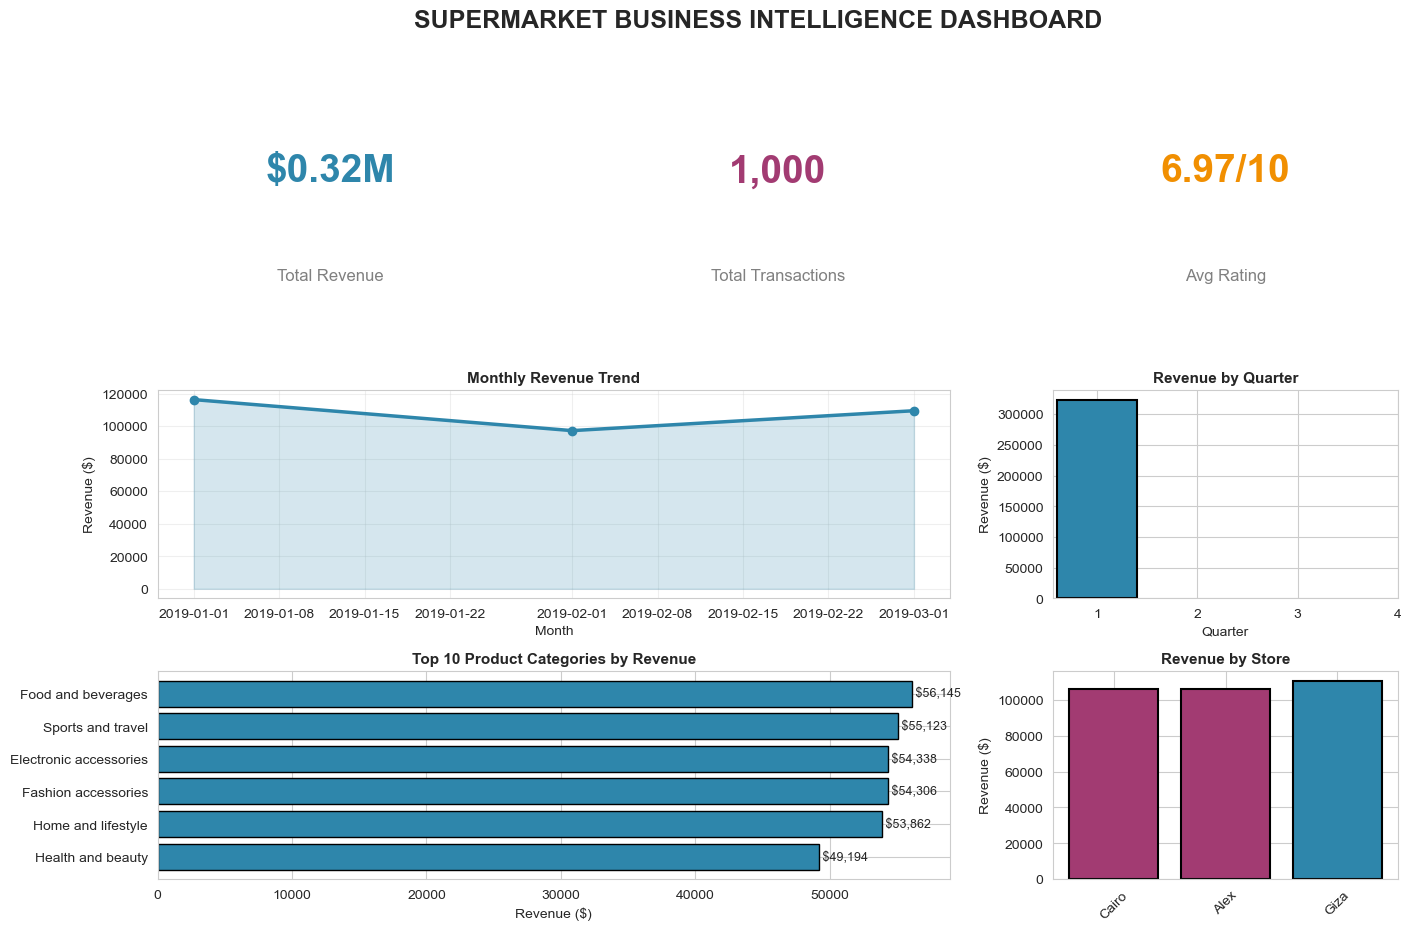

 Saved: 01_executive_dashboard.png


In [28]:
print("Creating Executive Dashboard...")

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

fig.suptitle('SUPERMARKET BUSINESS INTELLIGENCE DASHBOARD', fontsize=18, fontweight='bold', y=0.98)

# KPI Metrics (top row)
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.7, f"${sales['Revenue'].sum()/1e6:.2f}M", 
         ha='center', va='center', fontsize=28, fontweight='bold', color='#2E86AB')
ax1.text(0.5, 0.2, "Total Revenue", ha='center', va='center', fontsize=12, color='gray')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.7, f"{len(sales):,}", 
         ha='center', va='center', fontsize=28, fontweight='bold', color='#A23B72')
ax2.text(0.5, 0.2, "Total Transactions", ha='center', va='center', fontsize=12, color='gray')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.7, f"{sales['Rating'].mean():.2f}/10", 
         ha='center', va='center', fontsize=28, fontweight='bold', color='#F18F01')
ax3.text(0.5, 0.2, "Avg Rating", ha='center', va='center', fontsize=12, color='gray')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# Monthly Revenue Trend
ax4 = fig.add_subplot(gs[1, :2])
monthly = sales.groupby('YearMonth')['Revenue'].sum()
monthly.index = monthly.index.to_timestamp()
ax4.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, markersize=6, color='#2E86AB')
ax4.fill_between(monthly.index, monthly.values, alpha=0.2, color='#2E86AB')
ax4.set_title('Monthly Revenue Trend', fontweight='bold', fontsize=11)
ax4.set_xlabel('Month')
ax4.set_ylabel('Revenue ($)')
ax4.grid(True, alpha=0.3)

# Quarterly Distribution
ax5 = fig.add_subplot(gs[1, 2])
quarterly = sales.groupby('Quarter')['Revenue'].sum()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
ax5.bar(quarterly.index, quarterly.values, color=colors, edgecolor='black', linewidth=1.5)
ax5.set_title('Revenue by Quarter', fontweight='bold', fontsize=11)
ax5.set_xlabel('Quarter')
ax5.set_ylabel('Revenue ($)')
ax5.set_xticks([1, 2, 3, 4])

# Top Categories
ax6 = fig.add_subplot(gs[2, :2])
top_cats = sales.groupby('Category')['Revenue'].sum().sort_values().tail(10)
ax6.barh(range(len(top_cats)), top_cats.values, color='#2E86AB', edgecolor='black', linewidth=1)
ax6.set_yticks(range(len(top_cats)))
ax6.set_yticklabels(top_cats.index)
ax6.set_title('Top 10 Product Categories by Revenue', fontweight='bold', fontsize=11)
ax6.set_xlabel('Revenue ($)')
for i, v in enumerate(top_cats.values):
    ax6.text(v, i, f' ${v:,.0f}', va='center', fontsize=9)

# Store Performance
ax7 = fig.add_subplot(gs[2, 2])
store_revenue = sales.groupby('Store')['Revenue'].sum().sort_values()
colors_stores = ['#2E86AB' if x == store_revenue.max() else '#A23B72' for x in store_revenue.values]
ax7.bar(range(len(store_revenue)), store_revenue.values, color=colors_stores, edgecolor='black', linewidth=1.5)
ax7.set_xticks(range(len(store_revenue)))
ax7.set_xticklabels(store_revenue.index, rotation=45)
ax7.set_title('Revenue by Store', fontweight='bold', fontsize=11)
ax7.set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig('01_executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()  
print(" Saved: 01_executive_dashboard.png")

### # VISUALIZATION 2: TEMPORAL PATTERNS & SEASONALITY

Creating Temporal Analysis...


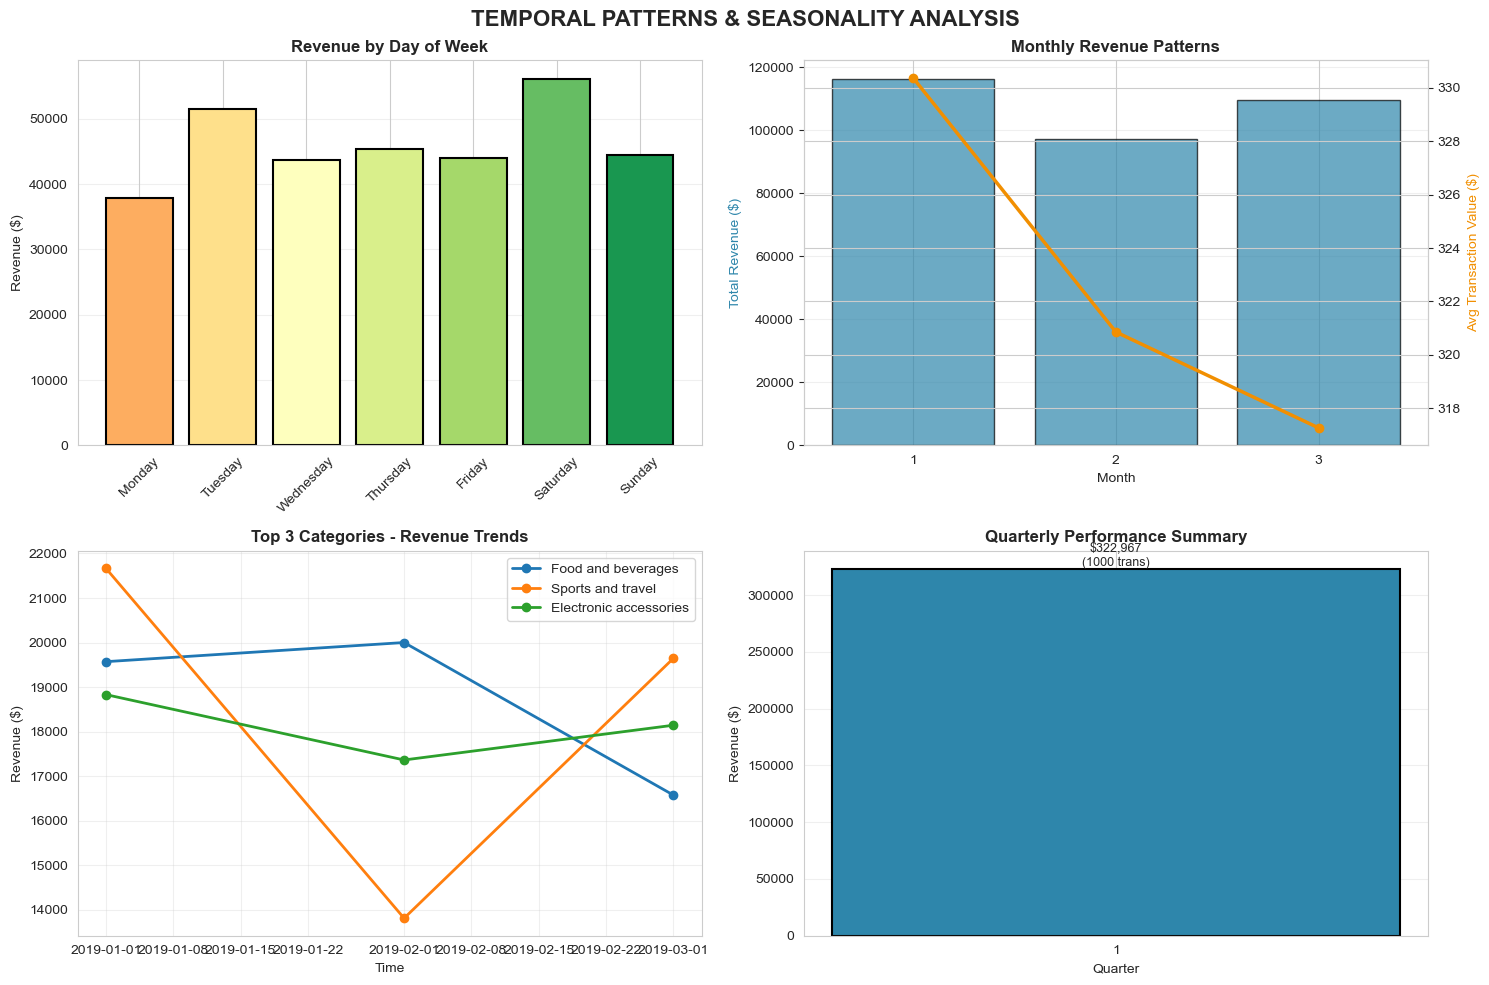

Saved: 02_temporal_patterns.png


In [29]:
print("Creating Temporal Analysis...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('TEMPORAL PATTERNS & SEASONALITY ANALYSIS', fontsize=16, fontweight='bold')

# Daily heatmap (Day of Week vs Hour)
ax = axes[0, 0]
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = sales.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)
colors_dow = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(dow_data)))
ax.bar(range(len(dow_data)), dow_data.values, color=colors_dow, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(dow_order)))
ax.set_xticklabels(dow_order, rotation=45)
ax.set_title('Revenue by Day of Week', fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.grid(True, alpha=0.3, axis='y')

# Monthly comparison
ax = axes[0, 1]
monthly_stats = sales.groupby('Month')['Revenue'].agg(['sum', 'mean', 'count'])
x = monthly_stats.index.tolist()  # Get only the months that exist
ax.bar(x, monthly_stats['sum'].values, color='#2E86AB', alpha=0.7, label='Total', edgecolor='black')
ax2 = ax.twinx()
ax2.plot(x, monthly_stats['mean'].values, color='#F18F01', marker='o', linewidth=2.5, markersize=6, label='Avg per Transaction')
ax.set_title('Monthly Revenue Patterns', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)', color='#2E86AB')
ax2.set_ylabel('Avg Transaction Value ($)', color='#F18F01')
ax.set_xticks(x)
ax.grid(True, alpha=0.3, axis='y')

# Category trends over time
ax = axes[1, 0]
top_3_cats = sales.groupby('Category')['Revenue'].sum().nlargest(3).index
for cat in top_3_cats:
    cat_monthly = sales[sales['Category'] == cat].groupby('YearMonth')['Revenue'].sum()
    cat_monthly.index = cat_monthly.index.to_timestamp()
    ax.plot(cat_monthly.index, cat_monthly.values, marker='o', label=cat, linewidth=2)
ax.set_title('Top 3 Categories - Revenue Trends', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Revenue ($)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Quarter comparison
ax = axes[1, 1]
quarter_data = sales.groupby('Quarter').agg({
    'Revenue': 'sum',
    'TransactionID': 'count',
    'Rating': 'mean'
})
x = range(1, len(quarter_data) + 1)  
colors_q = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'][:len(quarter_data)]  
ax.bar(x, quarter_data['Revenue'].values, color=colors_q, edgecolor='black', linewidth=1.5)
ax.set_title('Quarterly Performance Summary', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Revenue ($)')
ax.set_xticks(x)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(quarter_data['Revenue'].values, 1):
    ax.text(i, v, f"\n${v:,.0f}\n({quarter_data.iloc[i-1]['TransactionID']:.0f} trans)", 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('02_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show() 
print("Saved: 02_temporal_patterns.png")
plt.close()

In [30]:
print("Months with data:")
print(sales['Month'].value_counts().sort_index())

print("\nQuarters with data:")
print(sales['Quarter'].value_counts().sort_index())

Months with data:
Month
1    352
2    303
3    345
Name: count, dtype: int64

Quarters with data:
Quarter
1    1000
Name: count, dtype: int64


### VISUALIZATION 3: CUSTOMER SEGMENTATION & BEHAVIOR

Creating Customer Segmentation Analysis...


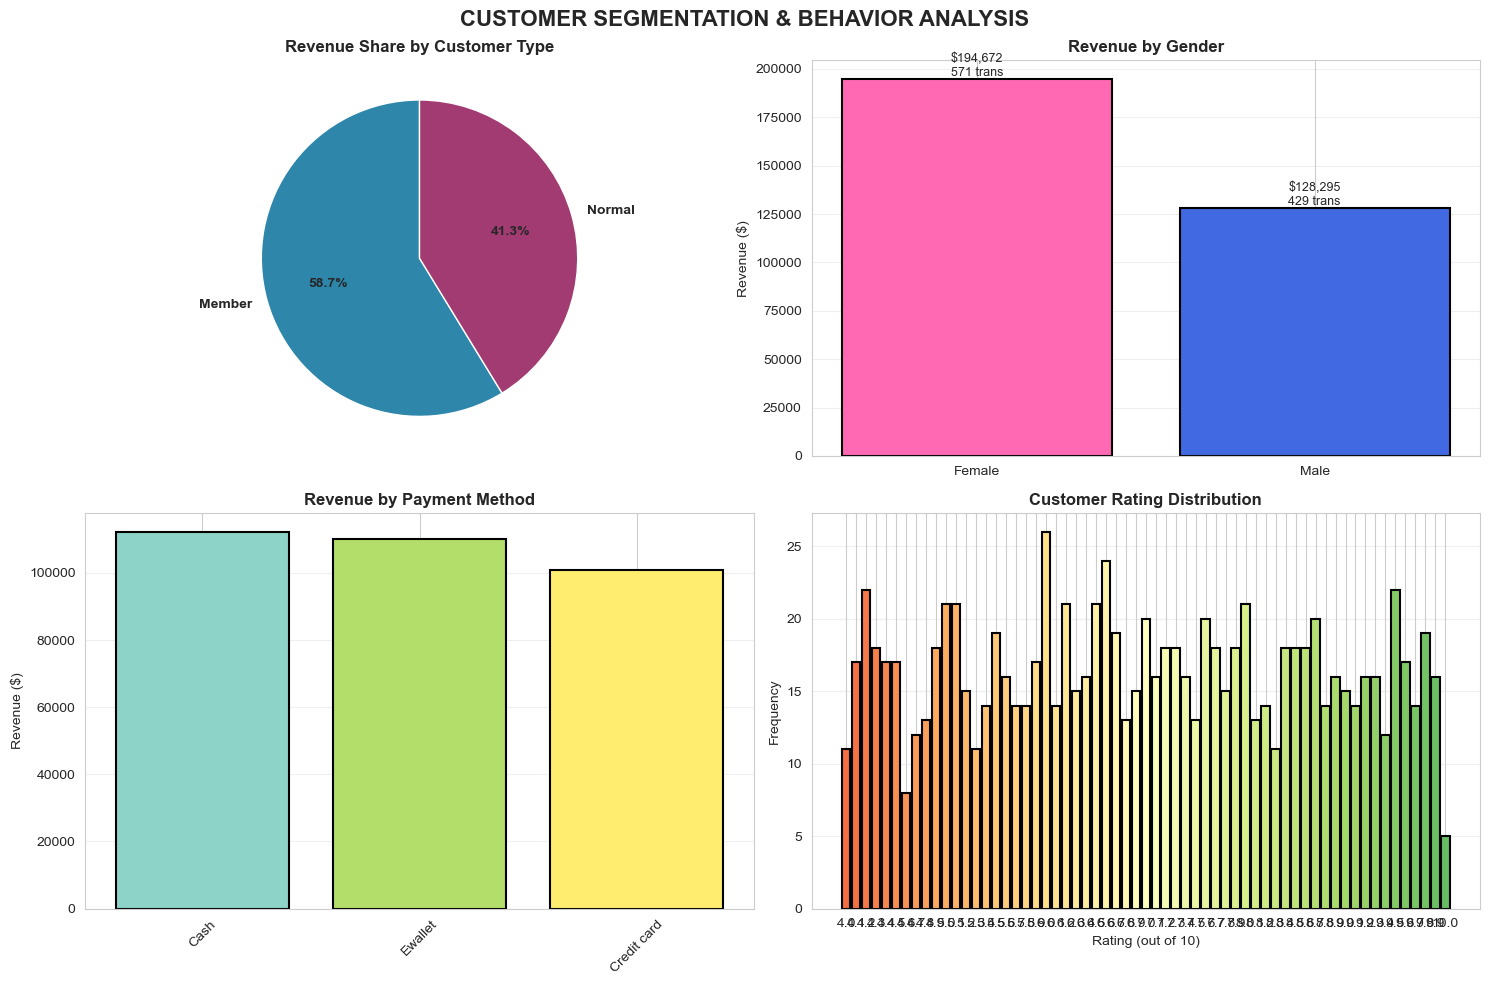

Saved: 03_customer_segmentation.png


In [31]:
print("Creating Customer Segmentation Analysis...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('CUSTOMER SEGMENTATION & BEHAVIOR ANALYSIS', fontsize=16, fontweight='bold')

# Customer Type Breakdown
ax = axes[0, 0]
cust_type = sales.groupby('CustomerType')['Revenue'].agg(['sum', 'count', 'mean'])
colors_ct = ['#2E86AB', '#A23B72']
wedges, texts, autotexts = ax.pie(cust_type['sum'].values, labels=cust_type.index, autopct='%1.1f%%',
                                    colors=colors_ct, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax.set_title('Revenue Share by Customer Type', fontweight='bold')

# Gender Analysis
ax = axes[0, 1]
gender = sales.groupby('Gender')['Revenue'].agg(['sum', 'count', 'mean'])
x_pos = range(len(gender))
ax.bar(x_pos, gender['sum'].values, color=['#FF69B4', '#4169E1'], edgecolor='black', linewidth=1.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(gender.index)
ax.set_title('Revenue by Gender', fontweight='bold')
ax.set_ylabel('Revenue ($)')
for i, v in enumerate(gender['sum'].values):
    ax.text(i, v, f'${v:,.0f}\n{gender.iloc[i]["count"]:.0f} trans', ha='center', va='bottom', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Payment Method Distribution
ax = axes[1, 0]
payment = sales.groupby('Payment')['Revenue'].sum().sort_values(ascending=False)
colors_pay = plt.cm.Set3(np.linspace(0, 1, len(payment)))
ax.bar(range(len(payment)), payment.values, color=colors_pay, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(payment)))
ax.set_xticklabels(payment.index, rotation=45)
ax.set_title('Revenue by Payment Method', fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.grid(True, alpha=0.3, axis='y')

# Rating Distribution
ax = axes[1, 1]
rating_counts = sales['Rating'].value_counts().sort_index()  
colors_rating = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(rating_counts)))
ax.bar(range(len(rating_counts)), rating_counts.values, 
       color=colors_rating, edgecolor='black', linewidth=1.5, width=0.85)  # ✅ Wider bars
ax.set_xticks(range(len(rating_counts)))
ax.set_xticklabels(rating_counts.index)
ax.set_title('Customer Rating Distribution', fontweight='bold')
ax.set_xlabel('Rating (out of 10)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlabel('Rating (out of 10)')


plt.tight_layout()
plt.savefig('03_customer_segmentation.png', dpi=300, bbox_inches='tight')
plt.show() 
print("Saved: 03_customer_segmentation.png")
plt.close()


### VISUALIZATION 4: STORE BENCHMARKING & COMPARISON

Creating Store Performance Benchmarking...


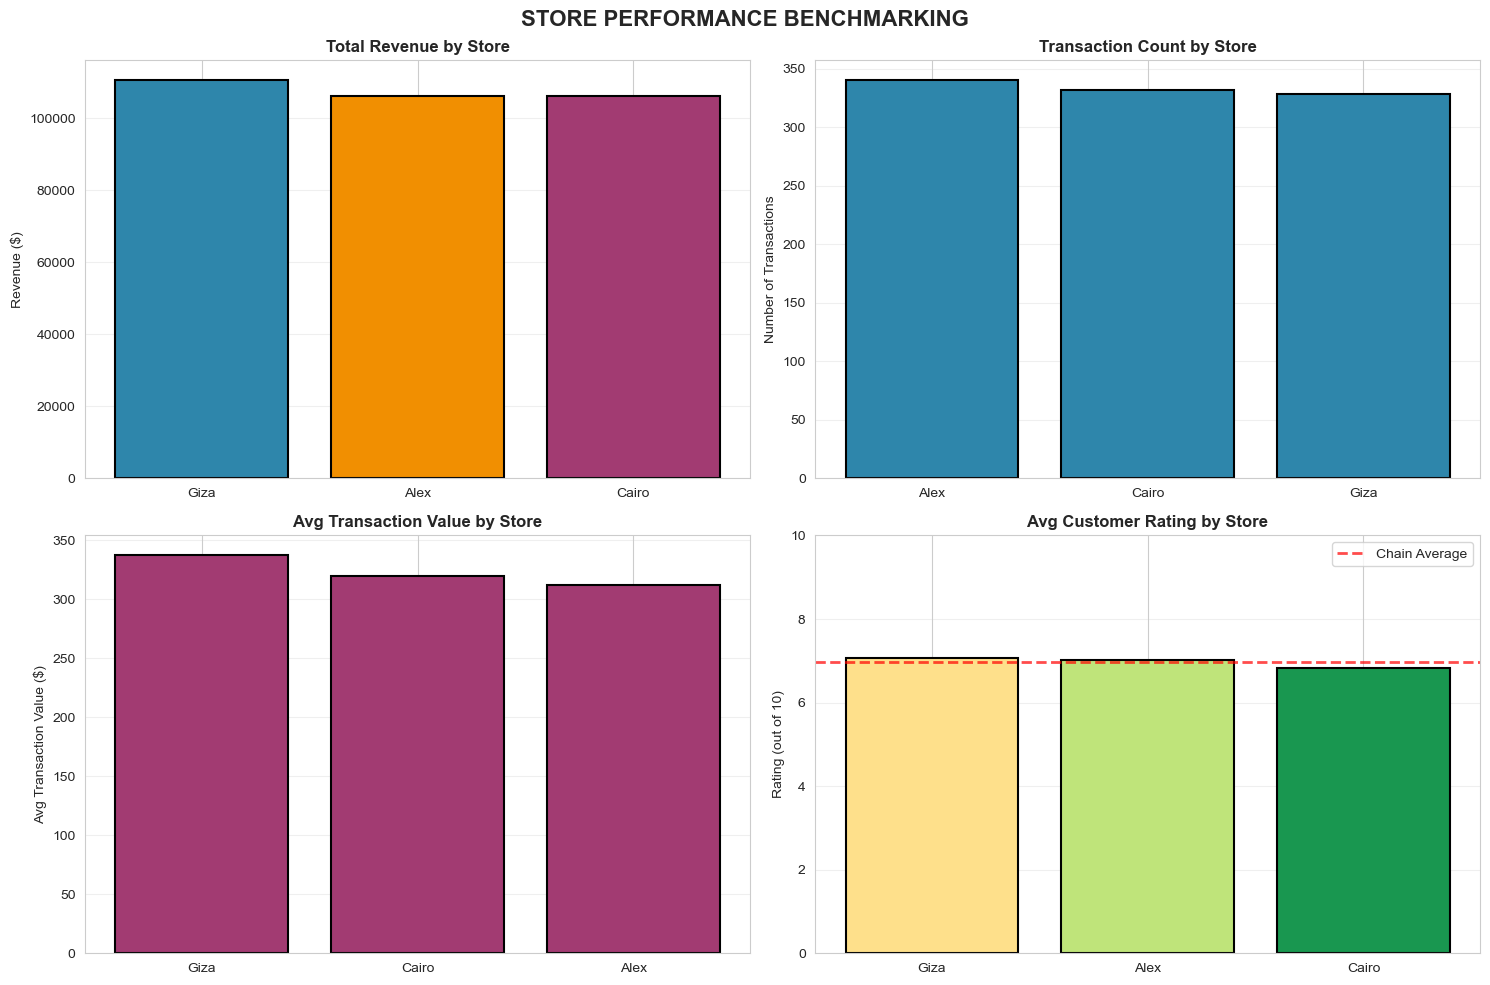

Saved: 04_store_benchmarking.png


In [32]:
print("Creating Store Performance Benchmarking...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('STORE PERFORMANCE BENCHMARKING', fontsize=16, fontweight='bold')

# Revenue by Store
ax = axes[0, 0]
store_rev = sales.groupby('Store')['Revenue'].sum().sort_values(ascending=False)
colors_store = ['#2E86AB' if i == 0 else '#A23B72' if i == len(store_rev)-1 else '#F18F01' for i in range(len(store_rev))]
ax.bar(range(len(store_rev)), store_rev.values, color=colors_store, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(store_rev)))
ax.set_xticklabels(store_rev.index)
ax.set_title('Total Revenue by Store', fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.grid(True, alpha=0.3, axis='y')

# Transaction Volume
ax = axes[0, 1]
store_trans = sales.groupby('Store')['TransactionID'].count().sort_values(ascending=False)
ax.bar(range(len(store_trans)), store_trans.values, color='#2E86AB', edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(store_trans)))
ax.set_xticklabels(store_trans.index)
ax.set_title('Transaction Count by Store', fontweight='bold')
ax.set_ylabel('Number of Transactions')
ax.grid(True, alpha=0.3, axis='y')

# Avg Transaction Value
ax = axes[1, 0]
store_avg = (sales.groupby('Store')['Revenue'].sum() / sales.groupby('Store')['TransactionID'].count()).sort_values(ascending=False)
ax.bar(range(len(store_avg)), store_avg.values, color='#A23B72', edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(store_avg)))
ax.set_xticklabels(store_avg.index)
ax.set_title('Avg Transaction Value by Store', fontweight='bold')
ax.set_ylabel('Avg Transaction Value ($)')
ax.grid(True, alpha=0.3, axis='y')

# Store Rating Comparison
ax = axes[1, 1]
store_rating = sales.groupby('Store')['Rating'].mean().sort_values(ascending=False)
colors_rating = plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(store_rating)))
ax.bar(range(len(store_rating)), store_rating.values, color=colors_rating, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(store_rating)))
ax.set_xticklabels(store_rating.index)
ax.set_title('Avg Customer Rating by Store', fontweight='bold')
ax.set_ylabel('Rating (out of 10)')
ax.set_ylim([0, 10])
ax.axhline(y=sales['Rating'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Chain Average')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('04_store_benchmarking.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 04_store_benchmarking.png")
plt.close()

### VISUALIZATION 5: CATEGORY HEATMAP & DEEP ANALYSIS

Creating Category Analysis Heatmap...


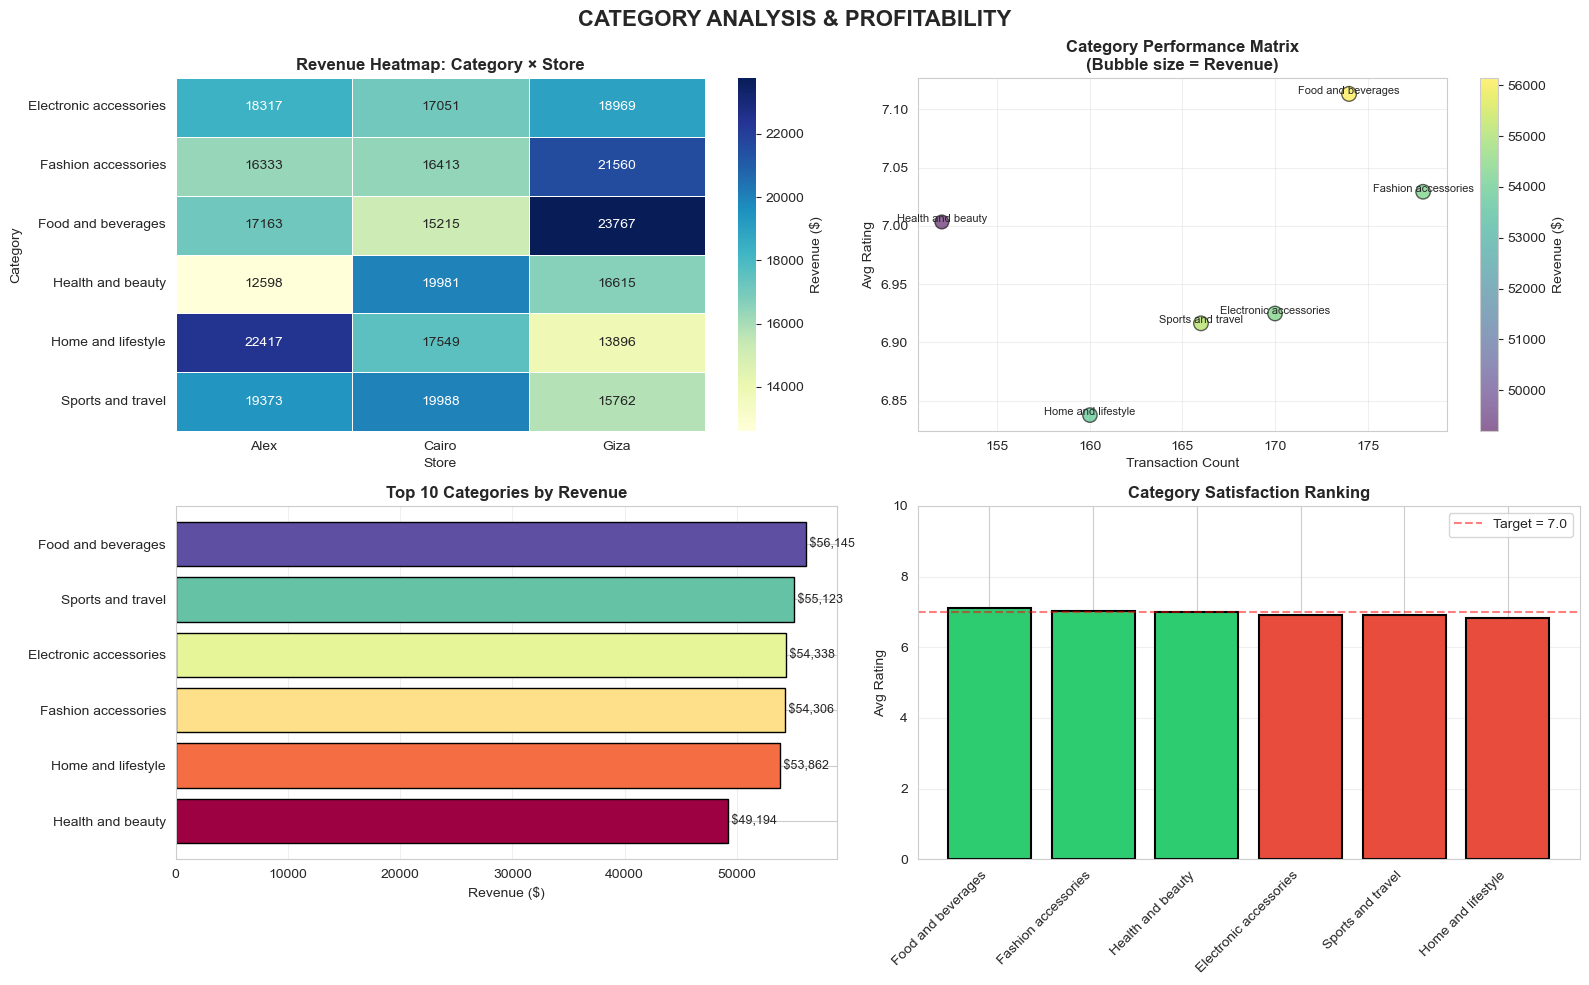

Saved: 05_category_analysis.png


In [33]:
print("Creating Category Analysis Heatmap...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('CATEGORY ANALYSIS & PROFITABILITY', fontsize=16, fontweight='bold')

# Store-Category Heatmap
ax = axes[0, 0]
store_cat_pivot = sales.pivot_table(values='Revenue', index='Category', columns='Store', aggfunc='sum')
sns.heatmap(store_cat_pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Revenue ($)'}, linewidths=0.5)
ax.set_title('Revenue Heatmap: Category × Store', fontweight='bold')

# Category Performance Scatter
ax = axes[0, 1]
cat_stats = sales.groupby('Category').agg({
    'Revenue': 'sum',
    'Rating': 'mean',
    'TransactionID': 'count'
})
scatter = ax.scatter(cat_stats['TransactionID'], cat_stats['Rating'], 
                     s=cat_stats['Revenue']/500, alpha=0.6, c=cat_stats['Revenue'], 
                     cmap='viridis', edgecolors='black', linewidth=1)
ax.set_xlabel('Transaction Count')
ax.set_ylabel('Avg Rating')
ax.set_title('Category Performance Matrix\n(Bubble size = Revenue)', fontweight='bold')
ax.grid(True, alpha=0.3)
for idx, row in cat_stats.iterrows():
    ax.annotate(idx, (row['TransactionID'], row['Rating']), fontsize=8, ha='center')
plt.colorbar(scatter, ax=ax, label='Revenue ($)')

# Top Categories Revenue
ax = axes[1, 0]
top_cat_rev = sales.groupby('Category')['Revenue'].sum().sort_values(ascending=True).tail(10)
ax.barh(range(len(top_cat_rev)), top_cat_rev.values, color=plt.cm.Spectral(np.linspace(0, 1, len(top_cat_rev))), 
        edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_cat_rev)))
ax.set_yticklabels(top_cat_rev.index)
ax.set_title('Top 10 Categories by Revenue', fontweight='bold')
ax.set_xlabel('Revenue ($)')
for i, v in enumerate(top_cat_rev.values):
    ax.text(v, i, f' ${v:,.0f}', va='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Category Rating vs Volume
ax = axes[1, 1]
cat_rating = sales.groupby('Category').agg({
    'Rating': 'mean',
    'TransactionID': 'count'
}).sort_values('Rating', ascending=False)
x_pos = range(len(cat_rating))
colors_cat = ['#2ECC71' if r >= 7 else '#E74C3C' if r < 7 else '#F39C12' for r in cat_rating['Rating']]
ax.bar(x_pos, cat_rating['Rating'].values, color=colors_cat, edgecolor='black', linewidth=1.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(cat_rating.index, rotation=45, ha='right')
ax.set_title('Category Satisfaction Ranking', fontweight='bold')
ax.set_ylabel('Avg Rating')
ax.set_ylim([0, 10])
ax.axhline(y=7, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Target = 7.0')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('05_category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 05_category_analysis.png")
plt.close()

### VISUALIZATION 6: SUMMARY REPORT CARD


Creating Summary Report Card...


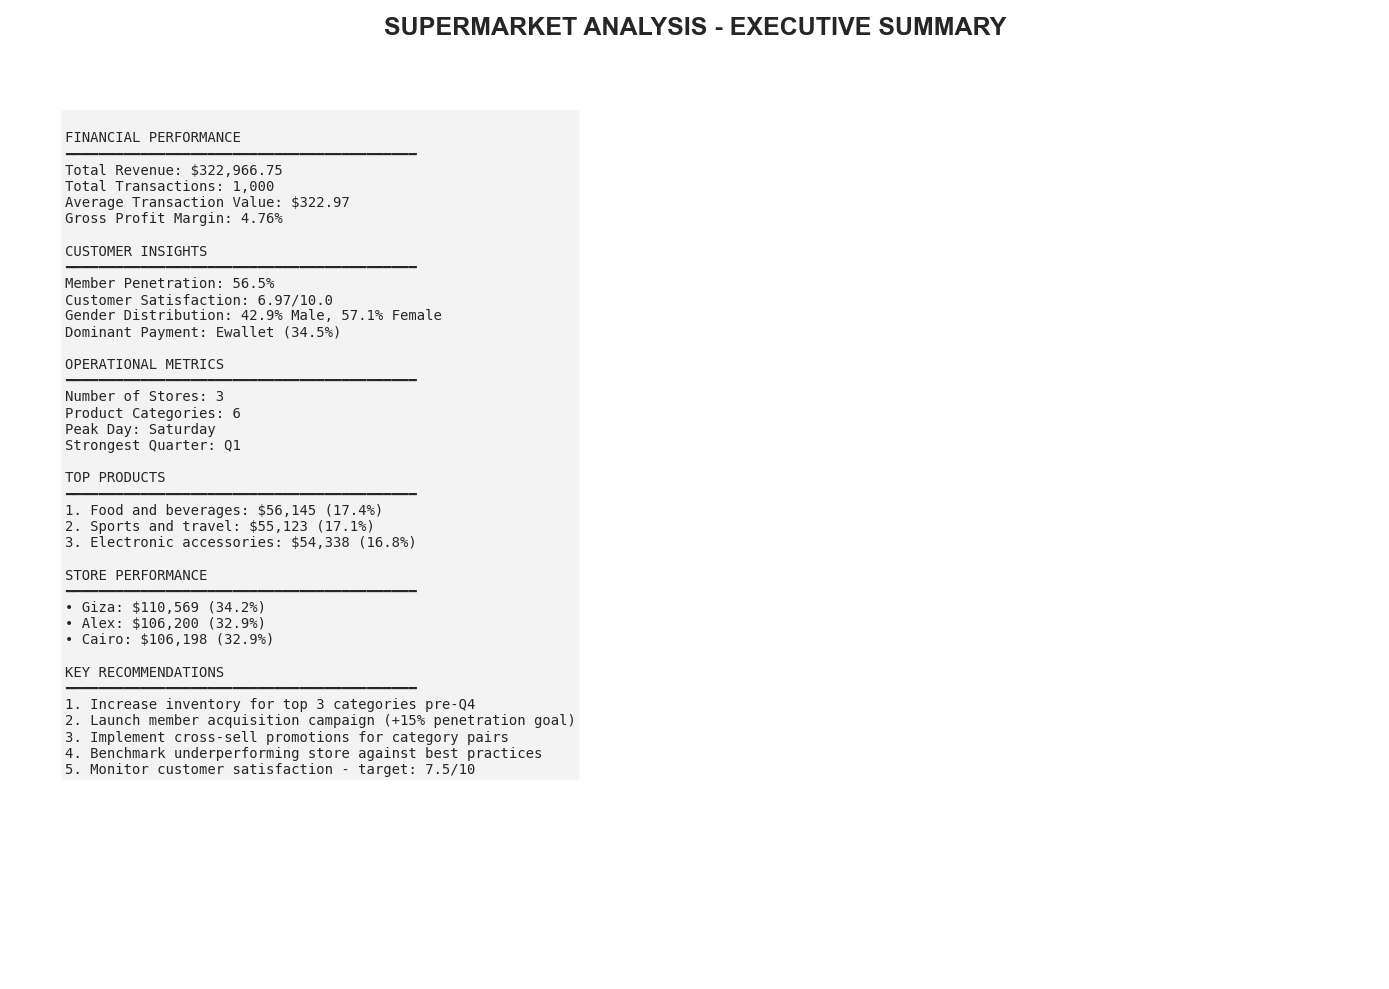

Saved: 06_summary_report_card.png


In [34]:
print("Creating Summary Report Card...")

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')

# Title
fig.text(0.5, 0.96, 'SUPERMARKET ANALYSIS - EXECUTIVE SUMMARY', 
         ha='center', fontsize=18, fontweight='bold')

# Key findings
findings_text = f"""
FINANCIAL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Revenue: ${sales['Revenue'].sum():,.2f}
Total Transactions: {len(sales):,}
Average Transaction Value: ${sales['Revenue'].mean():.2f}
Gross Profit Margin: {(sales['gross income'].sum() / sales['Revenue'].sum() * 100):.2f}%

CUSTOMER INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Member Penetration: {(sales[sales['CustomerType']=='Member'].shape[0]/len(sales)*100):.1f}%
Customer Satisfaction: {sales['Rating'].mean():.2f}/10.0
Gender Distribution: {(sales[sales['Gender']=='Male'].shape[0]/len(sales)*100):.1f}% Male, {(sales[sales['Gender']=='Female'].shape[0]/len(sales)*100):.1f}% Female
Dominant Payment: {sales['Payment'].value_counts().index[0]} ({sales['Payment'].value_counts().values[0]/len(sales)*100:.1f}%)

OPERATIONAL METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Number of Stores: {sales['Store'].nunique()}
Product Categories: {sales['Category'].nunique()}
Peak Day: {sales.groupby('DayOfWeek')['Revenue'].sum().idxmax()}
Strongest Quarter: Q{sales.groupby('Quarter')['Revenue'].sum().idxmax()}

TOP PRODUCTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

top_3 = sales.groupby('Category')['Revenue'].sum().nlargest(3)
for i, (cat, rev) in enumerate(top_3.items(), 1):
    pct = (rev / sales['Revenue'].sum()) * 100
    findings_text += f"{i}. {cat}: ${rev:,.0f} ({pct:.1f}%)\n"

findings_text += f"\nSTORE PERFORMANCE\n"
findings_text += f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"

store_perf = sales.groupby('Store')['Revenue'].sum().sort_values(ascending=False)
for store, rev in store_perf.items():
    pct = (rev / sales['Revenue'].sum()) * 100
    findings_text += f"• {store}: ${rev:,.0f} ({pct:.1f}%)\n"

findings_text += f"\nKEY RECOMMENDATIONS\n"
findings_text += f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
findings_text += "1. Increase inventory for top 3 categories pre-Q4\n"
findings_text += "2. Launch member acquisition campaign (+15% penetration goal)\n"
findings_text += "3. Implement cross-sell promotions for category pairs\n"
findings_text += "4. Benchmark underperforming store against best practices\n"
findings_text += "5. Monitor customer satisfaction - target: 7.5/10"

fig.text(0.05, 0.88, findings_text, fontfamily='monospace', fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#F0F0F0', alpha=0.8))

plt.axis('off')
plt.tight_layout()
plt.savefig('06_summary_report_card.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 06_summary_report_card.png")
plt.close()


In [35]:

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*80)


ALL VISUALIZATIONS COMPLETE!
